# STEMI External Validation — PTB-XL (STEMI-proxy qua Infarction Stadium)

**Dự án ACS-ECG-AI (Vinmec)** · nối tiếp [`08_stemi_stability_calibration.ipynb`](08_stemi_stability_calibration.ipynb)
· song song với [`09_external_validation_mimic.ipynb`](09_external_validation_mimic.ipynb)

## Mục đích

Kiểm tra model **Average Ensemble (8 kiến trúc)** đã chốt ở notebook `08` trên **PTB-XL** — nguồn dữ
liệu độc lập thứ hai, khác hẳn cơ chế gán nhãn so với MIMIC-IV-ECG-Ext-ICD (notebook `09`).

## ⚠️ Bản chất nhãn — đọc trước khi diễn giải kết quả

PTB-XL không có nhãn STEMI/NSTEMI trực tiếp. Notebook này dùng trường `infarction_stadium1` /
`infarction_stadium2` — phân loại **giai đoạn tiến triển hình thái ECG của nhồi máu cơ tim** (Stadium
I/II/III, trích xuất tự động từ report tiếng Đức/Anh gốc), không phải chẩn đoán lâm sàng STEMI theo
tiêu chuẩn ESC/AHA:

```
STEMI-proxy (dương)  = diagnostic_superclass chứa "MI"
                        AND (infarction_stadium1 == "Stadium I" OR infarction_stadium2 == "Stadium I")
Non-STEMI rõ (âm)     = diagnostic_superclass == {"NORM"}  (ECG bình thường, không MI)
```
Stadium I ứng với pha ST chênh lên/sóng T tối cấp — gần nhất với đặc điểm hình thái của STEMI trong 3
giai đoạn kinh điển, nhưng **không đảm bảo thoả tiêu chuẩn biên độ ST theo chuyển đạo/tuổi/giới** như
định nghĩa STEMI lâm sàng chính thức.

## Vì sao dùng song song với MIMIC (notebook 09) — hai nguồn lỗi nhãn khác nhau, bổ trợ nhau

| | PTB-XL Stadium I (notebook này) | MIMIC ICD (notebook 09) |
|---|---|---|
| Bản chất nhãn | Hình thái ECG tại thời điểm đọc | Mã hành chính chẩn đoán ra viện |
| Rủi ro chính | NLP trích từ report tiếng Đức, dữ liệu 1989–1996 | Lệch thời gian ECG–biến cố |
| Gắn với ECG tại thời điểm | Có (trực tiếp) | Không đảm bảo (gián tiếp) |

Nếu Sensitivity/AUPRC **nhất quán** trên cả hai nguồn → bằng chứng generalize mạnh hơn nhiều so với
chỉ một nguồn. Nếu lệch nhau → gợi ý model nhạy với kiểu nhiễu nhãn cụ thể, cũng là thông tin hữu ích.

## Vì sao không cần lấy mẫu 10% như MIMIC

PTB-XL đã được tải sẵn về Drive (`VinAMI_ACS/data/ptb-xl/1.0.3/`) — đọc trực tiếp từ đó, không tải lại,
không cần lấy mẫu ở bước dữ liệu như MIMIC-IV-ECG (90 GB, phải tải có chọn lọc). Việc lọc theo Stadium I
chỉ áp dụng ở bước **chọn nhãn**, không phải bước đọc dữ liệu.


## 1. Cài thư viện

In [1]:
!pip install -q wfdb
import importlib.util
import os
import sys
print("Python:", sys.version.split()[0])


Python: 3.13.15


## 2. Cấu hình

Đường dẫn khớp với các checkpoint/OOF đã dùng ở notebook 08/09. **Sửa `DRIVE_PROJECT` nếu khác.**


In [2]:
import os
from pathlib import Path
import torch

IS_COLAB = importlib.util.find_spec("google.colab") is not None
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
PERSIST_DIR   = DRIVE_PROJECT / "outputs"

# ---- Đường dẫn checkpoint / OOF (giống hệt notebook 08, 09) ----
KFOLD_MODEL_DIR = PERSIST_DIR / "models" / "stemi_kfold_holdout"   # checkpoint FINAL (8 kiến trúc)
OOF_NPZ_PATH    = PERSIST_DIR / "oof" / "oof_STEMI_full_k5r1_holdout.npz"
ACS_CACHE_DIR   = PERSIST_DIR / "cache"                            # cache tín hiệu ACS-ECG 2026 đã lọc

# ---- Dữ liệu gốc ACS-ECG 2026 (để khôi phục POOL_IDX + mean_pool/std_pool giống hệt notebook 08) ----
DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"          # <<< SỬA nếu tên zip khác
ACS_DATA_ROOT  = Path("/content/datasets_acs")           # giải nén cục bộ để đọc train.csv

# ---- PTB-XL: đã tải sẵn trên Drive (VinAMI_ACS), đọc trực tiếp -- KHÔNG tải lại ----
PTBXL_DRIVE_DIR = Path("/content/drive/MyDrive/VinAMI_ACS/data/ptb-xl/1.0.3")   # <<< SỬA nếu khác

# ---- Nơi lưu output của notebook này ----
EXT_PERSIST = PERSIST_DIR / "external_validation" / "ptbxl_stadium"   # bền qua các phiên, lưu về Drive
EXT_PERSIST.mkdir(parents=True, exist_ok=True)

# ---- Tham số mô hình / tín hiệu -- PHẢI khớp notebook 08 ----
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12       # 12 chuyển đạo x 10s @ 500Hz
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3        # bandpass Butterworth -- giống notebook 08
TARGET_LABEL = "STEMI"
CANDIDATES = ["PlainCNN", "XResNet1D", "ConvNeXtV2_1D", "AiTiAMI", "ResNet1D",
              "SEResNet1D", "CNN+BiLSTM", "InceptionTime1D"]   # 8 ứng viên, giống notebook 08
TARGET_SENS_PRIMARY = 0.91    # chính sách ngưỡng STEMI đã dùng trong báo cáo (khớp mục 23a notebook 08)

# ---- Tham số lọc nhãn PTB-XL ----
STADIUM_POSITIVE = "Stadium I"          # giai đoạn coi là STEMI-proxy
MIN_LIKELIHOOD = 0                      # lọc độ tin cậy statement MI (0-100); 0 = không lọc
MAX_NEG_SAMPLES = 999999                  # chặn trên số ca âm (NORM) lấy mẫu, tránh quá tải bộ nhớ
RANDOM_STATE = SEED

GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
BATCH_SIZE = 64 if GPU_AVAILABLE else 16

print("Thiết bị        :", DEVICE)
print("Checkpoint FINAL:", KFOLD_MODEL_DIR)
print("OOF             :", OOF_NPZ_PATH)
print("Cache ACS-ECG   :", ACS_CACHE_DIR)
print("PTB-XL (Drive)  :", PTBXL_DRIVE_DIR, "--",
      "TỒN TẠI" if PTBXL_DRIVE_DIR.exists() else "!! KHÔNG THẤY")
print("Output ngoài    :", EXT_PERSIST)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thiết bị        : cuda
Checkpoint FINAL: /content/drive/MyDrive/ACS-ECG-AI/outputs/models/stemi_kfold_holdout
OOF             : /content/drive/MyDrive/ACS-ECG-AI/outputs/oof/oof_STEMI_full_k5r1_holdout.npz
Cache ACS-ECG   : /content/drive/MyDrive/ACS-ECG-AI/outputs/cache
PTB-XL (Drive)  : /content/drive/MyDrive/VinAMI_ACS/data/ptb-xl/1.0.3 -- TỒN TẠI
Output ngoài    : /content/drive/MyDrive/ACS-ECG-AI/outputs/external_validation/ptbxl_stadium


## 3. Tám kiến trúc model

Copy **nguyên văn** từ notebook `08` (mục 12) — bắt buộc giống hệt để `load_state_dict` không lỗi
lệch kiến trúc. Không sửa bất kỳ tham số nào ở đây.


In [3]:
import torch
import torch.nn as nn


# ---------------------------------------------------------------- 1. PlainCNN
class PlainCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in channels:
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------- 2. ResNet1D
class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ResNet1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 3. InceptionTime1D
class InceptionModule(nn.Module):
    def __init__(self, c_in, n_filters=32, kernels=(39, 19, 9), bottleneck=32):
        super().__init__()
        self.bottleneck = nn.Conv1d(c_in, bottleneck, 1, bias=False)
        self.convs = nn.ModuleList(
            [nn.Conv1d(bottleneck, n_filters, k, padding=k // 2, bias=False) for k in kernels])
        self.pool_conv = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                       nn.Conv1d(c_in, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * (len(kernels) + 1))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b = self.bottleneck(x)
        return self.relu(self.bn(torch.cat([c(b) for c in self.convs] + [self.pool_conv(x)], 1)))


class InceptionTime1D(nn.Module):
    def __init__(self, n_filters=32, depth=6):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 4, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        c_out = n_filters * 4
        self.blocks = nn.ModuleList()
        self.shortcuts = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = 32
        res_c = 32
        for d in range(depth):
            self.blocks.append(InceptionModule(c_in, n_filters))
            if d % 3 == 2:
                self.shortcuts.append(nn.Sequential(nn.Conv1d(res_c, c_out, 1, bias=False),
                                                    nn.BatchNorm1d(c_out)))
                self.pools.append(nn.MaxPool1d(4))
                res_c = c_out
            else:
                self.shortcuts.append(None)
                self.pools.append(None)
            c_in = c_out
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_out, 1))

    def forward(self, x):
        x = self.stem(x)
        res = x
        for blk, short, pool in zip(self.blocks, self.shortcuts, self.pools):
            x = blk(x)
            if short is not None:
                x = self.relu(x + short(res))
                x = pool(x)
                res = x
        return self.head(x).squeeze(-1)


# ---------------------------------------------------------------- 4. CNN + BiLSTM
class CNNBiLSTM(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in (32, 64, 128):
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.cnn = nn.Sequential(*layers)
        self.lstm = nn.LSTM(c_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden * 2, 1))

    def forward(self, x):
        h = self.cnn(x).transpose(1, 2)
        out, _ = self.lstm(h)
        return self.head(out.mean(dim=1)).squeeze(-1)


# ---------------------------------------------------------------- 5. SEResNet1D
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True),
                                nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        w = self.fc(self.pool(x).squeeze(-1)).unsqueeze(-1)
        return x * w


class SEResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.se = SEBlock1D(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.se(self.bn2(self.conv2(out)))
        return self.relu(out + idt)


class SEResNet1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(SEResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 6. XResNet1D
class XResBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.act = nn.SiLU(inplace=True)
        if stride == 1 and c_in == c_out:
            self.short = nn.Identity()
        else:
            self.short = nn.Sequential(
                nn.AvgPool1d(stride, ceil_mode=True), nn.Conv1d(c_in, c_out, 1, bias=False),
                nn.BatchNorm1d(c_out))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.act(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class XResNet1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(NUM_LEADS, 32, 5, 2, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(XResBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.SiLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 7. ConvNeXtV2_1D
class GRN1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, channels))
        self.beta = nn.Parameter(torch.zeros(1, 1, channels))

    def forward(self, x):
        gx = torch.norm(x, p=2, dim=1, keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * nx) + self.beta + x


class ConvNeXtV2Block1D(nn.Module):
    def __init__(self, channels, expand=4, dropout=0.1):
        super().__init__()
        self.dwconv = nn.Conv1d(channels, channels, 7, padding=3, groups=channels, bias=False)
        self.norm = nn.LayerNorm(channels)
        self.pw1 = nn.Linear(channels, channels * expand)
        self.act = nn.GELU()
        self.grn = GRN1D(channels * expand)
        self.pw2 = nn.Linear(channels * expand, channels)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        idt = x
        x = self.dwconv(x).transpose(1, 2)
        x = self.norm(x)
        x = self.pw2(self.grn(self.act(self.pw1(x))))
        x = self.drop(x).transpose(1, 2)
        return x + idt


class ConvNeXtV2Downsample1D(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.norm = nn.BatchNorm1d(c_in)
        self.conv = nn.Conv1d(c_in, c_out, 2, stride=2, bias=False)

    def forward(self, x):
        return self.conv(self.norm(x))


class ConvNeXtV2_1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), depths=(1, 1, 2, 1), dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, channels[0], 4, stride=4, bias=False),
                                  nn.BatchNorm1d(channels[0]))
        stages, c_in = [], channels[0]
        for stage_i, (c_out, depth) in enumerate(zip(channels, depths)):
            if stage_i > 0:
                stages.append(ConvNeXtV2Downsample1D(c_in, c_out))
            stages += [ConvNeXtV2Block1D(c_out, dropout=dropout) for _ in range(depth)]
            c_in = c_out
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.LayerNorm(c_in), nn.Dropout(dropout), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.stages(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 8. AiTiAMI
class AiTiAMIBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=5, stride=2, dropout=0.15):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class AiTiAMI(nn.Module):
    def __init__(self, channels=(48, 96, 192, 256, 320), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 48, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(48), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 48
        for i, c_out in enumerate(channels):
            blocks.append(AiTiAMIBlock1D(c_in, c_out, stride=2 if i < 4 else 1))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_in * 2, 128), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x):
        feat = self.blocks(self.stem(x))
        pooled = torch.cat([self.avgpool(feat), self.maxpool(feat)], dim=1)
        return self.head(pooled).squeeze(-1)


MODELS = {
    "PlainCNN": PlainCNN, "ResNet1D": ResNet1D, "InceptionTime1D": InceptionTime1D,
    "CNN+BiLSTM": CNNBiLSTM, "SEResNet1D": SEResNet1D, "XResNet1D": XResNet1D,
    "ConvNeXtV2_1D": ConvNeXtV2_1D, "AiTiAMI": AiTiAMI,
}
print("Đã định nghĩa", len(MODELS), "kiến trúc:", ", ".join(MODELS.keys()))


Đã định nghĩa 8 kiến trúc: PlainCNN, ResNet1D, InceptionTime1D, CNN+BiLSTM, SEResNet1D, XResNet1D, ConvNeXtV2_1D, AiTiAMI


## 4. Khôi phục chuẩn hoá (mean/std) và ngưỡng vận hành từ ACS-ECG 2026

Checkpoint FINAL chỉ lưu `state_dict`, **không lưu** `mean_pool`/`std_pool` dùng để z-score lúc train.
Phải tính lại đúng như notebook `08` (mục 14c): `norm_stats(POOL_IDX)` trên **đúng tập POOL** (85%
bệnh nhân, sau khi tách 15% TEST). Nếu chuẩn hoá sai, xác suất đầu ra sẽ lệch hệ thống dù model đúng.

Cần `train.csv` gốc (trong `datasets.zip`) để tái tạo đúng `POOL_IDX` — **cùng `SEED=42`,
`TEST_SIZE=0.15`, cùng logic chia theo bệnh nhân** như notebook 08. Sau đó dùng **cache tín hiệu đã
có sẵn trên Drive** (không tính lại từ đầu, chỉ cần thống kê mean/std).


In [4]:
import shutil
import zipfile

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

if not ACS_DATA_ROOT.exists() or not any(ACS_DATA_ROOT.rglob("train.csv")):
    print("Giải nén datasets.zip ...")
    ACS_DATA_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DRIVE_DATA_ZIP) as zf:
        # chỉ cần train.csv để khôi phục POOL_IDX -- không cần giải nén toàn bộ .dat/.hea (rất nặng)
        csv_members = [n for n in zf.namelist() if n.lower().endswith("train.csv")]
        assert csv_members, "Không tìm thấy train.csv trong datasets.zip"
        zf.extract(csv_members[0], ACS_DATA_ROOT)
    print("Xong.")

_train_csv = next(ACS_DATA_ROOT.rglob("train.csv"))
df_raw = pd.read_csv(_train_csv)
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)
COL_PATIENT = "Patient_id"

df_all = df_raw.copy()
df_all[TARGET_LABEL] = df_all["STEMI"].astype(int)
df_acs = df_all.reset_index(drop=True)          # RUN_MODE="full" trong notebook 08 -> df == df_all
y_acs = df_acs[TARGET_LABEL].values.astype(np.float32)

# ---- Tái tạo ĐÚNG POOL/TEST split của notebook 08 (mục 12b) ----
TEST_SIZE = 0.15
pat_all = df_acs.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
pat_pool, pat_test = train_test_split(pat_all, test_size=TEST_SIZE,
                                      stratify=pat_all[TARGET_LABEL], random_state=SEED + 200)
TEST_PATIENTS = set(pat_test[COL_PATIENT])
IS_TEST = df_acs[COL_PATIENT].isin(TEST_PATIENTS).to_numpy()
POOL_IDX = df_acs.index[~IS_TEST].to_numpy()
TEST_IDX = df_acs.index[IS_TEST].to_numpy()
assert not (set(df_acs.loc[POOL_IDX, COL_PATIENT]) & TEST_PATIENTS), "RÒ RỈ: bệnh nhân TEST lọt vào POOL"
print(f"POOL: {len(POOL_IDX):,} bản ghi | TEST: {len(TEST_IDX):,} bản ghi "
      f"(khớp lại đúng split của notebook 08)")

# ---- Định vị cache đã build sẵn (hash giống hệt logic notebook 08, mục 7) ----
import hashlib

records = df_acs["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
_cache_candidates = list(ACS_CACHE_DIR.glob(f"sig_full_n{len(df_acs)}_{_hash}.npy"))
assert _cache_candidates, (
    f"Không tìm thấy cache khớp hash tại {ACS_CACHE_DIR} -- kiểm tra ACS_CACHE_DIR hoặc "
    f"train.csv có đúng bản đã dùng để train không.")
CACHE_ACS = np.load(_cache_candidates[0], mmap_mode="r")
print("Cache ACS-ECG 2026:", CACHE_ACS.shape, CACHE_ACS.dtype, "--", _cache_candidates[0].name)


def norm_stats(idx, cache, chunk=256):
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS); ss = np.zeros(NUM_LEADS); cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(cache[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2)); ss += (b ** 2).sum(axis=(0, 2)); cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


mean_pool, std_pool = norm_stats(POOL_IDX, CACHE_ACS)
print("mean_pool:", np.round(mean_pool, 4))
print("std_pool :", np.round(std_pool, 4))


POOL: 15,279 bản ghi | TEST: 2,681 bản ghi (khớp lại đúng split của notebook 08)
Cache ACS-ECG 2026: (17960, 12, 5000) float16 -- sig_full_n17960_c20c6dba.npy
mean_pool: [-0.0001  0.0004  0.0002  0.0001 -0.0004  0.0004 -0.0002  0.      0.0003
  0.0002  0.0001  0.0002]
std_pool : [0.4318 0.4686 0.4878 0.4612 0.4632 0.4855 0.5005 0.5792 0.5563 0.5456
 0.6324 0.7319]


## 5. Khôi phục ngưỡng vận hành từ OOF (Average Ensemble, Sensitivity ≥ 91%)

Đúng phương pháp luận notebook 08: **chốt ngưỡng từ OOF trên POOL, áp nguyên xi lên tập ngoài** — không
refit trên MIMIC. Dùng `Average-CV` (trung bình xác suất 8 model) vì đây là model tốt nhất hiện tại
theo anh xác nhận.


In [5]:
OOF = np.load(OOF_NPZ_PATH)
y_oof = OOF["y"]
OOF_P = {name: OOF[f"p_{name}"][0] for name in CANDIDATES}     # rep 0
VALID = np.isfinite(OOF_P[CANDIDATES[0]])
print(f"OOF phủ {VALID.sum():,}/{len(y_oof):,} bản ghi | {int(y_oof[VALID].sum())} ca dương")

OOF_AVG = np.mean([OOF_P[n] for n in CANDIDATES], axis=0)


def threshold_at_sensitivity(y_true, y_prob, target_sens):
    """Giống hệt notebook 08 (mục 17b): ngưỡng LỚN NHẤT sao cho Sensitivity thực tế >= target."""
    y_true = np.asarray(y_true).astype(int)
    pos_scores = np.sort(y_prob[y_true == 1])[::-1]
    n_pos = len(pos_scores)
    k = min(int(np.ceil(target_sens * n_pos)), n_pos)
    return float(pos_scores[k - 1]) if k > 0 else 1.0


THRESHOLD = threshold_at_sensitivity(y_oof[VALID], OOF_AVG[VALID], TARGET_SENS_PRIMARY)
print(f"Ngưỡng Average Ensemble @ Sensitivity >= {TARGET_SENS_PRIMARY:.0%} (chốt từ POOL OOF): "
      f"{THRESHOLD:.4f}")


OOF phủ 15,279/17,960 bản ghi | 1225 ca dương
Ngưỡng Average Ensemble @ Sensitivity >= 91% (chốt từ POOL OOF): 0.2417


## 6. Trỏ tới PTB-XL đã có sẵn trên Drive — không tải lại

Đọc trực tiếp từ `VinAMI_ACS/data/ptb-xl/1.0.3/` trên Drive (đã tải sẵn, cấu trúc gồm `records500/`,
`records100/`, `ptbxl_database.csv`, `scp_statements.csv`...). **Không đụng vào `v2_training_cache_v1`
— thư mục đó thuộc dự án khác.**

Đọc trực tiếp qua Drive-mount sẽ chậm hơn đĩa cục bộ (I/O của Google Drive với nhiều file nhỏ), nhưng
đổi lại không tốn thời gian/dung lượng tải lại. Nếu về sau thấy quá chậm, có thể copy toàn bộ
`records500/` sang `/content/` một lần rồi đọc từ đó.


In [6]:
assert PTBXL_DRIVE_DIR.exists(), (
    f"Không thấy {PTBXL_DRIVE_DIR} -- kiểm tra lại đường dẫn PTBXL_DRIVE_DIR ở mục 2.")

_required = ["ptbxl_database.csv", "scp_statements.csv", "records500"]
_missing = [f for f in _required if not (PTBXL_DRIVE_DIR / f).exists()]
assert not _missing, f"Thiếu {_missing} trong {PTBXL_DRIVE_DIR} -- kiểm tra lại cấu trúc thư mục."

_ptbxl_base = PTBXL_DRIVE_DIR
print("Đọc PTB-XL trực tiếp từ Drive:", _ptbxl_base)
print("  records500/ :", "OK" if (_ptbxl_base / "records500").exists() else "THIẾU")
print("  ptbxl_database.csv :", "OK" if (_ptbxl_base / "ptbxl_database.csv").exists() else "THIẾU")


Đọc PTB-XL trực tiếp từ Drive: /content/drive/MyDrive/VinAMI_ACS/data/ptb-xl/1.0.3
  records500/ : OK
  ptbxl_database.csv : OK


## 7. Nạp `ptbxl_database.csv` + `scp_statements.csv`, xác định superclass MI/NORM

Theo đúng quy trình chuẩn được PTB-XL khuyến nghị (example code chính thức): parse `scp_codes`
(dict dạng chuỗi) → đối chiếu `scp_statements.csv` để lấy `diagnostic_class` → gộp thành
`diagnostic_superclass` cho từng bản ghi.


In [7]:
import ast

import numpy as np
import pandas as pd

df_ptb = pd.read_csv(_ptbxl_base / "ptbxl_database.csv", index_col="ecg_id")
df_ptb.scp_codes = df_ptb.scp_codes.apply(ast.literal_eval)

agg_df = pd.read_csv(_ptbxl_base / "scp_statements.csv", index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]


def aggregate_diagnostic(y_dic):
    classes = set()
    for code, likelihood in y_dic.items():
        if code in agg_df.index and likelihood >= MIN_LIKELIHOOD:
            classes.add(agg_df.loc[code].diagnostic_class)
    return classes


df_ptb["diagnostic_superclass"] = df_ptb.scp_codes.apply(aggregate_diagnostic)
df_ptb["is_mi"] = df_ptb["diagnostic_superclass"].apply(lambda s: "MI" in s)
df_ptb["is_norm_only"] = df_ptb["diagnostic_superclass"].apply(lambda s: s == {"NORM"})

print(f"{len(df_ptb):,} bản ghi | MI superclass: {int(df_ptb['is_mi'].sum()):,} | "
      f"NORM thuần: {int(df_ptb['is_norm_only'].sum()):,}")


21,799 bản ghi | MI superclass: 5,469 | NORM thuần: 9,069


## 8. Lọc STEMI-proxy theo `infarction_stadium1`/`infarction_stadium2`

**Đếm thực tế trước khi quyết định dùng được hay không** — như đã thảo luận, không giả định số lượng.


In [8]:
print("Phân bố infarction_stadium1 (chỉ trong nhóm MI):")
display(df_ptb.loc[df_ptb["is_mi"], "infarction_stadium1"].value_counts(dropna=False))
print("\nPhân bố infarction_stadium2 (chỉ trong nhóm MI):")
display(df_ptb.loc[df_ptb["is_mi"], "infarction_stadium2"].value_counts(dropna=False))

df_ptb["_is_stemi_proxy"] = df_ptb["is_mi"] & (
    (df_ptb["infarction_stadium1"] == STADIUM_POSITIVE) |
    (df_ptb["infarction_stadium2"] == STADIUM_POSITIVE))

df_stemi = df_ptb[df_ptb["_is_stemi_proxy"]].copy()
df_neg = df_ptb[df_ptb["is_norm_only"]].copy()

print(f"\nSTEMI-proxy (Stadium I)  : {len(df_stemi):,} bản ghi")
print(f"Non-STEMI rõ (NORM thuần) : {len(df_neg):,} bản ghi")

if len(df_stemi) < 30:
    print(f"\n!! CẢNH BÁO: chỉ có {len(df_stemi)} ca dương -- quá ít để tính Sensitivity/AUPRC có ý "
          f"nghĩa thống kê. Cân nhắc mở rộng STADIUM_POSITIVE sang cả \"Stadium I-II\" (mục 2) nếu "
          f"cần thêm mẫu, và nêu rõ giới hạn này khi báo cáo.")


Phân bố infarction_stadium1 (chỉ trong nhóm MI):


,count
infarction_stadium1,
unknown,3372
Stadium III,949
Stadium II-III,910
Stadium I,146
Stadium II,88
Stadium I-II,4



Phân bố infarction_stadium2 (chỉ trong nhóm MI):


,count
infarction_stadium2,
NaN,5367
Stadium III,64
Stadium I,19
Stadium II,19



STEMI-proxy (Stadium I)  : 146 bản ghi
Non-STEMI rõ (NORM thuần) : 9,069 bản ghi


## 9. Lấy mẫu — giữ 100% dương, giới hạn số âm (tránh quá tải bộ nhớ khi tiền xử lý)


In [9]:
rng = np.random.default_rng(RANDOM_STATE)

n_neg_take = min(len(df_neg), MAX_NEG_SAMPLES)
df_neg_sample = df_neg.sample(n=n_neg_take, random_state=RANDOM_STATE)

df_sample = pd.concat([
    df_stemi.assign(label=1),
    df_neg_sample.assign(label=0),
])
df_sample = df_sample.reset_index()   # đưa ecg_id thành cột

print(f"Mẫu external validation: {len(df_sample):,} bản ghi "
      f"({int(df_sample['label'].sum())} STEMI-proxy dương, "
      f"{int((df_sample['label']==0).sum())} âm)")
display(df_sample[["ecg_id", "filename_hr", "infarction_stadium1", "infarction_stadium2",
                   "label"]].head())


Mẫu external validation: 9,215 bản ghi (146 STEMI-proxy dương, 9069 âm)


,ecg_id,filename_hr,infarction_stadium1,infarction_stadium2,label
0,189,records500/00000/00189_hr,Stadium I,Stadium I,1
1,514,records500/00000/00514_hr,Stadium I,NaN,1
2,532,records500/00000/00532_hr,Stadium I,NaN,1
3,1063,records500/01000/01063_hr,Stadium I,Stadium I,1
4,2253,records500/02000/02253_hr,Stadium I,Stadium I,1


## 10. Tiền xử lý tín hiệu PTB-XL

**Giống hệt notebook 08/09** (bandpass Butterworth [0,5–40] Hz bậc 3, pad/crop về 5000 mẫu). Đọc bản
500 Hz (`filename_hr`) để khớp `FS=500`. Vẫn chủ động sắp lại thứ tự 12 chuyển đạo theo `sig_name`
trong header thay vì giả định — cùng nguyên tắc phòng ngừa như notebook MIMIC.


In [10]:
import wfdb
from scipy.signal import butter, filtfilt

CANON_LEAD_ORDER = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")


def load_and_reorder(stem_path: Path):
    rec = wfdb.rdrecord(str(stem_path))
    idx_map = {}
    for lead in CANON_LEAD_ORDER:
        matches = [i for i, s in enumerate(rec.sig_name) if s.strip().upper() == lead.upper()]
        if not matches:
            return None, f"thiếu lead {lead}"
        idx_map[lead] = matches[0]
    order = [idx_map[l] for l in CANON_LEAD_ORDER]
    sig = np.asarray(rec.p_signal, dtype=np.float32)[:, order].T   # (12, n_samples)
    return sig, None


def preprocess_ext(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


EXT_ARR = np.zeros((len(df_sample), NUM_LEADS, SIGNAL_LEN), dtype=np.float32)
EXT_OK = np.zeros(len(df_sample), dtype=bool)
_skip_reasons = []
for i, rel in enumerate(df_sample["filename_hr"]):
    stem_path = _ptbxl_base / rel
    try:
        sig, err = load_and_reorder(stem_path)
        if err:
            _skip_reasons.append((rel, err))
            continue
        EXT_ARR[i] = preprocess_ext(sig)
        EXT_OK[i] = True
    except Exception as e:
        _skip_reasons.append((rel, f"{type(e).__name__}: {e}"))

print(f"Tiền xử lý xong: {EXT_OK.sum():,}/{len(df_sample):,} bản ghi hợp lệ")
if _skip_reasons:
    print(f"  {len(_skip_reasons)} bản ghi bị loại, ví dụ:")
    for s, r in _skip_reasons[:10]:
        print(f"    {s}: {r}")

df_sample = df_sample[EXT_OK].reset_index(drop=True)
EXT_ARR = EXT_ARR[EXT_OK]
y_ext = df_sample["label"].values.astype(np.float32)
print(f"\nTập external cuối cùng: {len(df_sample):,} bản ghi "
      f"({int(y_ext.sum())} STEMI-proxy dương, {y_ext.mean():.2%})")

# ---- Kiểm tra sớm: mất hết 1 lớp sau đọc file thường KHÔNG phải lỗi gán nhãn (mục 7-9 đã đếm ------
# ---- đúng 146 dương / 4000 âm trước khi đọc), mà do Google Drive mount bị ngắt kết nối giữa chừng --
n_pos_ok = int(y_ext.sum())
n_neg_ok = int(len(y_ext) - n_pos_ok)
if n_pos_ok == 0 or n_neg_ok == 0:
    raise RuntimeError(
        f"Sau tiền xử lý chỉ còn 1 lớp duy nhất ({n_pos_ok} dương / {n_neg_ok} âm) -- đây KHÔNG phải "
        "lỗi gán nhãn ở mục 7-9 (đã đếm đúng 146 dương / 4000 âm trước khi đọc file). Nguyên nhân "
        "thường gặp: Google Drive bị ngắt kết nối giữa chừng khi đọc hàng loạt file WFDB (xem lỗi "
        "'OSError: [Errno 107] Transport endpoint is not connected' ở trên -- một khi FUSE mount của "
        "Drive crash, MỌI đường dẫn phía sau trong vòng lặp đều báo FileNotFoundError dù file vẫn tồn "
        "tại thật). Khắc phục: chạy drive.mount(\"/content/drive\", force_remount=True) rồi chạy lại "
        "từ mục 6 (không chỉ mục 10) để Drive ổn định trước khi đọc lại toàn bộ.")

Tiền xử lý xong: 9,215/9,215 bản ghi hợp lệ

Tập external cuối cùng: 9,215 bản ghi (146 STEMI-proxy dương, 1.58%)


## 11. Nạp 8 checkpoint FINAL và dự đoán ensemble Average


In [11]:
from torch.utils.data import DataLoader, Dataset


class ExtDataset(Dataset):
    def __init__(self, arr, labels, mean, std):
        self.arr = arr
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = mean.reshape(-1, 1)
        self.std = std.reshape(-1, 1)

    def __len__(self):
        return len(self.arr)

    def __getitem__(self, i):
        x = self.arr[i]
        return torch.from_numpy((x - self.mean) / self.std), torch.tensor(self.labels[i])


ext_loader = DataLoader(ExtDataset(EXT_ARR, y_ext, mean_pool, std_pool),
                        batch_size=BATCH_SIZE, shuffle=False)


def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            ys.append(yb.numpy())
            ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    y_out, p_out = np.concatenate(ys), np.concatenate(ps)
    bad = ~np.isfinite(p_out)
    if bad.any():
        p_out = np.where(bad, 0.5, p_out)
    return y_out, p_out


EXT_P = {}
for name in CANDIDATES:
    ckpt_path = KFOLD_MODEL_DIR / f"{name.replace('+', '_')}_FINAL_pool.pt"
    assert ckpt_path.exists(), f"Không tìm thấy checkpoint {ckpt_path}"
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = MODELS[name]().to(DEVICE)
    model.load_state_dict(ck["model"])
    _, p = evaluate(model, ext_loader)
    EXT_P[name] = p
    del model
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()
    print(f"  {name}: xong")

EXT_P["Average Ensemble"] = np.mean([EXT_P[n] for n in CANDIDATES], axis=0)
print("\nĐã dự đoán xong 8 model đơn + Average Ensemble trên tập external PTB-XL.")


  PlainCNN: xong
  XResNet1D: xong
  ConvNeXtV2_1D: xong
  AiTiAMI: xong
  ResNet1D: xong
  SEResNet1D: xong
  CNN+BiLSTM: xong
  InceptionTime1D: xong

Đã dự đoán xong 8 model đơn + Average Ensemble trên tập external PTB-XL.


## 12. Áp ngưỡng đã chốt từ POOL — tính metric đầy đủ trên PTB-XL

**Không refit ngưỡng** — dùng nguyên `THRESHOLD` đã tính ở mục 5 (từ OOF trên ACS-ECG 2026), đúng
phương pháp luận notebook 08 và notebook 09.


In [12]:
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             roc_auc_score)


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


rows = []
for name in CANDIDATES + ["Average Ensemble"]:
    m = compute_metrics(y_ext, EXT_P[name], THRESHOLD if name == "Average Ensemble" else 0.5)
    rows.append({"Model": name, **m})
ext_results_df = pd.DataFrame(rows).set_index("Model")

print("=" * 78)
print(f"EXTERNAL VALIDATION -- PTB-XL (STEMI-proxy qua Infarction Stadium I), "
      f"{len(df_sample):,} bản ghi")
print(f"Ngưỡng Average Ensemble @ Sensitivity >= {TARGET_SENS_PRIMARY:.0%} (chốt từ ACS-ECG 2026 "
      f"POOL, KHÔNG refit): {THRESHOLD:.4f}")
print("=" * 78)
display(ext_results_df[["auroc", "auprc", "sensitivity", "specificity", "ppv", "npv", "f1",
                        "n", "n_pos"]].round(4))

_champ = ext_results_df.loc["Average Ensemble"]
print(f"\nAverage Ensemble trên PTB-XL: AUROC {_champ['auroc']:.4f} | "
      f"Sensitivity {_champ['sensitivity']:.4f} | Specificity {_champ['specificity']:.4f} | "
      f"NPV {_champ['npv']:.4f} | PPV {_champ['ppv']:.4f}")


EXTERNAL VALIDATION -- PTB-XL (STEMI-proxy qua Infarction Stadium I), 9,215 bản ghi
Ngưỡng Average Ensemble @ Sensitivity >= 91% (chốt từ ACS-ECG 2026 POOL, KHÔNG refit): 0.2417


,auroc,auprc,sensitivity,specificity,ppv,npv,f1,n,n_pos
Model,,,,,,,,,
PlainCNN,0.9489,0.6015,0.7740,0.9572,0.2255,0.9962,0.3493,9215,146
XResNet1D,0.9720,0.7604,0.6918,0.9961,0.7426,0.9950,0.7163,9215,146
ConvNeXtV2_1D,0.9794,0.7661,0.6712,0.9974,0.8033,0.9947,0.7313,9215,146
AiTiAMI,0.9905,0.7982,0.7740,0.9966,0.7847,0.9964,0.7793,9215,146
ResNet1D,0.9864,0.7176,0.7740,0.9860,0.4708,0.9963,0.5855,9215,146
SEResNet1D,0.9853,0.7251,0.8014,0.9836,0.4398,0.9968,0.5680,9215,146
CNN+BiLSTM,0.9879,0.7177,0.7192,0.9914,0.5738,0.9955,0.6383,9215,146
InceptionTime1D,0.9665,0.7147,0.6644,0.9954,0.6978,0.9946,0.6807,9215,146
Average Ensemble,0.9907,0.8042,0.8904,0.9814,0.4348,0.9982,0.5843,9215,146



Average Ensemble trên PTB-XL: AUROC 0.9907 | Sensitivity 0.8904 | Specificity 0.9814 | NPV 0.9982 | PPV 0.4348


## 13. Đối chiếu ba nguồn: ACS-ECG 2026 (nội bộ) — MIMIC-IV-ECG — PTB-XL

Điền thủ công kết quả từ notebook 08 (mục 21d) và notebook 09 (mục 13) để so trên cùng một bảng.


In [13]:
print("Đối chiếu Average Ensemble qua các nguồn (điền tay 2 dòng đầu từ notebook 08/09):")
print(f"{'Nguồn':<28}{'AUROC':>8}{'Sensitivity':>13}{'Specificity':>13}{'NPV':>8}{'PPV':>8}")
print(f"{'ACS-ECG 2026 TEST (nb 08)':<28}{'?':>8}{'?':>13}{'?':>13}{'?':>8}{'?':>8}")
print(f"{'MIMIC-IV-ECG (nb 09)':<28}{'?':>8}{'?':>13}{'?':>13}{'?':>8}{'?':>8}")
print(f"{'PTB-XL (notebook này)':<28}{_champ['auroc']:>8.4f}{_champ['sensitivity']:>13.4f}"
      f"{_champ['specificity']:>13.4f}{_champ['npv']:>8.4f}{_champ['ppv']:>8.4f}")


Đối chiếu Average Ensemble qua các nguồn (điền tay 2 dòng đầu từ notebook 08/09):
Nguồn                          AUROC  Sensitivity  Specificity     NPV     PPV
ACS-ECG 2026 TEST (nb 08)          ?            ?            ?       ?       ?
MIMIC-IV-ECG (nb 09)               ?            ?            ?       ?       ?
PTB-XL (notebook này)         0.9907       0.8904       0.9814  0.9982  0.4348


CONFUSION MATRIX (TP/FN/FP/TN) -- từng kiến trúc + Average Ensemble, PTB-XL
(Average Ensemble dùng ngưỡng 0.2417; 8 kiến trúc đơn lẻ dùng ngưỡng mặc định 0.5)


,tp,fn,fp,tn,n,n_pos,sensitivity_check,specificity_check
Model,,,,,,,,
PlainCNN,113,33,388,8681,9215,146,0.7740,0.9572
XResNet1D,101,45,35,9034,9215,146,0.6918,0.9961
ConvNeXtV2_1D,98,48,24,9045,9215,146,0.6712,0.9974
AiTiAMI,113,33,31,9038,9215,146,0.7740,0.9966
ResNet1D,113,33,127,8942,9215,146,0.7740,0.9860
SEResNet1D,117,29,149,8920,9215,146,0.8014,0.9836
CNN+BiLSTM,105,41,78,8991,9215,146,0.7192,0.9914
InceptionTime1D,97,49,42,9027,9215,146,0.6644,0.9954
Average Ensemble,130,16,169,8900,9215,146,0.8904,0.9814



Average Ensemble trên PTB-XL -- ngưỡng 0.2417
                         Dự đoán DƯƠNG    Dự đoán ÂM      Tổng
Thực DƯƠNG (Stadium I)             130            16       146
        Thực ÂM (NORM)             169         8,900     9,069
                  Tổng             299         8,916     9,215

TP=130  FN=16  FP=169  TN=8,900
Sensitivity = TP/(TP+FN) = 130/146 = 0.8904
Specificity = TN/(TN+FP) = 8900/9069 = 0.9814
PPV         = TP/(TP+FP) = 130/299 = 0.4348
NPV         = TN/(TN+FN) = 8900/8916 = 0.9982


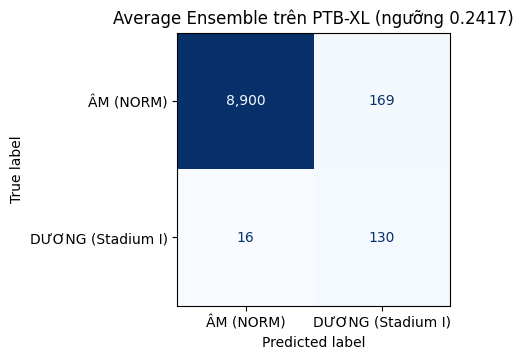

In [14]:
# ---- 12b. Confusion matrix chi tiết (TP/FP/FN/TN) -- không tính lại gì, chỉ đọc từ ext_results_df ----
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_cols = ["tp", "fn", "fp", "tn", "n", "n_pos"]
cm_df = ext_results_df[cm_cols].copy()
cm_df["sensitivity_check"] = (cm_df["tp"] / (cm_df["tp"] + cm_df["fn"])).round(4)
cm_df["specificity_check"] = (cm_df["tn"] / (cm_df["tn"] + cm_df["fp"])).round(4)

print("=" * 78)
print("CONFUSION MATRIX (TP/FN/FP/TN) -- từng kiến trúc + Average Ensemble, PTB-XL")
print(f"(Average Ensemble dùng ngưỡng {THRESHOLD:.4f}; 8 kiến trúc đơn lẻ dùng ngưỡng mặc định 0.5)")
print("=" * 78)
display(cm_df)

# ---- Bảng 2x2 chi tiết cho model chốt (Average Ensemble) ----
_champ_name = "Average Ensemble"
_cm = ext_results_df.loc[_champ_name]
tp, fn, fp, tn = int(_cm["tp"]), int(_cm["fn"]), int(_cm["fp"]), int(_cm["tn"])

print("\n" + "=" * 60)
print(f"{_champ_name} trên PTB-XL -- ngưỡng {THRESHOLD:.4f}")
print("=" * 60)
print(f"{'':>22}{'Dự đoán DƯƠNG':>16}{'Dự đoán ÂM':>14}{'Tổng':>10}")
print(f"{'Thực DƯƠNG (Stadium I)':>22}{tp:>16,}{fn:>14,}{tp + fn:>10,}")
print(f"{'Thực ÂM (NORM)':>22}{fp:>16,}{tn:>14,}{fp + tn:>10,}")
print(f"{'Tổng':>22}{tp + fp:>16,}{fn + tn:>14,}{tp + fp + fn + tn:>10,}")
print(f"\nTP={tp:,}  FN={fn:,}  FP={fp:,}  TN={tn:,}")
print(f"Sensitivity = TP/(TP+FN) = {tp}/{tp + fn} = {tp / (tp + fn):.4f}")
print(f"Specificity = TN/(TN+FP) = {tn}/{tn + fp} = {tn / (tn + fp):.4f}")
print(f"PPV         = TP/(TP+FP) = {tp}/{tp + fp} = {tp / (tp + fp):.4f}")
print(f"NPV         = TN/(TN+FN) = {tn}/{tn + fn} = {tn / (tn + fn):.4f}")

# ---- Heatmap trực quan ----
fig, ax = plt.subplots(figsize=(4.5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=np.array([[tn, fp], [fn, tp]]),
                              display_labels=["ÂM (NORM)", "DƯƠNG (Stadium I)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
ax.set_title(f"{_champ_name} trên PTB-XL (ngưỡng {THRESHOLD:.4f})")
plt.tight_layout()
plt.show()


## 14. Lưu kết quả về Drive


In [15]:
import json as _json

ext_results_df.to_csv(EXT_PERSIST / "external_validation_ptbxl_results.csv")
np.savez_compressed(EXT_PERSIST / "external_validation_ptbxl_predictions.npz",
                    y=y_ext, ecg_id=df_sample["ecg_id"].to_numpy(),
                    **{f"p_{n}": EXT_P[n] for n in CANDIDATES},
                    p_average=EXT_P["Average Ensemble"])
(EXT_PERSIST / "run_meta.json").write_text(_json.dumps({
    "threshold": THRESHOLD, "target_sensitivity": TARGET_SENS_PRIMARY,
    "n_total": len(df_sample), "n_pos": int(y_ext.sum()),
    "stadium_positive": STADIUM_POSITIVE, "min_likelihood": MIN_LIKELIHOOD,
}, indent=2))
print("Đã lưu:", EXT_PERSIST)


Đã lưu: /content/drive/MyDrive/ACS-ECG-AI/outputs/external_validation/ptbxl_stadium


## 15. Hạn chế cần nêu khi báo cáo kết quả này

- **Nhãn là STEMI-proxy qua giai đoạn ECG (Stadium I)**, trích tự động từ report gốc tiếng Đức/Anh —
  không phải chẩn đoán STEMI lâm sàng theo tiêu chuẩn ESC/AHA, không xác nhận qua chụp mạch vành.
- **Cỡ mẫu dương có thể nhỏ** (kiểm tra thực tế ở mục 8) — nếu ít, khoảng tin cậy của Sensitivity/AUPRC
  sẽ rất rộng, tránh diễn giải quá mức từ một con số điểm.
- **Dữ liệu 1989–1996, dân số Đức** — khác hẳn ACS-ECG 2026 về thời gian, thiết bị ghi, dân số. Chênh
  lệch hiệu năng một phần phản ánh domain shift, không chỉ chất lượng model.
- **Nhóm âm chỉ gồm NORM thuần** — không bao gồm các bất thường khác (STTC/CD/HYP không kèm MI), nên
  Specificity đo được ở đây **lạc quan hơn** so với thực tế lâm sàng (không kiểm tra khả năng phân biệt
  STEMI với các bất thường ECG khác, ví dụ LBBB, phì đại thất). Notebook 09 (MIMIC) và bộ Georgia/SPH
  đã bàn trước đó phù hợp hơn cho việc kiểm tra specificity trước các bất thường không phải MI.
- Kết quả nên được trình bày như **kiểm chứng bổ sung mang tính khám phá**, đối chiếu song song với
  notebook 09, không thay thế kết quả TEST nội bộ của notebook 08.
